In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from models.TimesNet import Model

配置信息

In [10]:
class Config:
    def __init__(self):
        self.task_name = 'short_term_forecast'  # 任务类型
        self.seq_len = 30  # 输入序列长度
        self.pred_len = 3  # 预测长度
        self.enc_in = 1  # 输入维度
        self.dec_in = 1  # 解码器输入维度
        self.c_out = 1  # 输出维度
        self.d_model = 30  # 模型维度
        self.dropout = 0.1  # dropout率
        self.num_kernels = 6  # 卷积核数量
        self.d_ff = 50  # 前馈网络维度
        self.top_k = 3  # FFT周期数
        self.e_layers = 2  # 编码器层数
        self.batch_size = 32
        self.learning_rate = 0.0001
        self.epochs = 100

        # 不使用时间嵌入，则以下参数不生效
        self.embed = 'timeF'  # 时间特征编码
        self.freq = 'h'  # 时间频率

        # 只有Autoformer 会用到这个参数
        self.label_len = 48  # 标签长度

加载数据

数据样式为：[批大小, 序列长度, 特征数]，需要可自定义输入序列长度、输出序列长度

In [11]:
class TimeSeriesDataset(Dataset):  
    def __init__(self, data, seq_len, pred_len):  
        self.data = torch.FloatTensor(data)  
        self.seq_len = seq_len  
        self.pred_len = pred_len  
        
    def __len__(self):  
        return len(self.data) - self.seq_len - self.pred_len + 1  
    
    def __getitem__(self, index):  
        x = self.data[index:index+self.seq_len]  
        y = self.data[index+self.seq_len:index+self.seq_len+self.pred_len]  
        
        return x, y

模型训练

In [12]:
# 训练函数  
def train_model(model, train_loader, optimizer, criterion, device):  
    model.train()  
    total_loss = 0  
    for batch_x, batch_y in train_loader:  
        optimizer.zero_grad()  
        
        batch_x = batch_x.to(device)  
        batch_y = batch_y.to(device)  
        
        # 前向传播  
        outputs = model(batch_x, None, None, None)  
        
        loss = criterion(outputs, batch_y)  
        total_loss += loss.item()  
        
        # 反向传播  
        loss.backward()  
        optimizer.step()  
        
    return total_loss / len(train_loader)  

In [14]:
# 评估函数  
def evaluate_model(model, test_loader, criterion, device):  
    model.eval()  
    total_loss = 0  
    predictions = []  
    actuals = []  
    
    with torch.no_grad():  
        for batch_x, batch_y in test_loader:  
            batch_x = batch_x.to(device)  
            batch_y = batch_y.to(device)  
            
            outputs = model(batch_x, None, None, None)  
            loss = criterion(outputs, batch_y)  
            total_loss += loss.item()  
            
            predictions.extend(outputs.cpu().numpy())  
            actuals.extend(batch_y.cpu().numpy())  
    
    return total_loss / len(test_loader), np.array(predictions), np.array(actuals) 

Epoch 1/100
Train Loss: 1.1491, Test Loss: 1.2216
Epoch 2/100
Train Loss: 1.1291, Test Loss: 1.2054
Epoch 3/100
Train Loss: 1.0885, Test Loss: 1.1947
Epoch 4/100
Train Loss: 1.0896, Test Loss: 1.2019
Epoch 5/100
Train Loss: 1.0704, Test Loss: 1.1945
Epoch 6/100
Train Loss: 1.0799, Test Loss: 1.1984
Epoch 7/100
Train Loss: 1.0810, Test Loss: 1.2006
Epoch 8/100
Train Loss: 1.0569, Test Loss: 1.1979
Epoch 9/100
Train Loss: 1.0510, Test Loss: 1.1999
Epoch 10/100
Train Loss: 1.0676, Test Loss: 1.1932
Epoch 11/100
Train Loss: 1.0586, Test Loss: 1.1974
Epoch 12/100
Train Loss: 1.0401, Test Loss: 1.2014
Epoch 13/100
Train Loss: 1.0535, Test Loss: 1.2017
Epoch 14/100
Train Loss: 1.0421, Test Loss: 1.2037
Epoch 15/100
Train Loss: 1.0337, Test Loss: 1.2083
Epoch 16/100
Train Loss: 1.0137, Test Loss: 1.2070
Epoch 17/100
Train Loss: 1.0136, Test Loss: 1.2151
Epoch 18/100
Train Loss: 1.0084, Test Loss: 1.2154
Epoch 19/100
Train Loss: 1.0140, Test Loss: 1.2196
Epoch 20/100
Train Loss: 1.0148, Test Lo

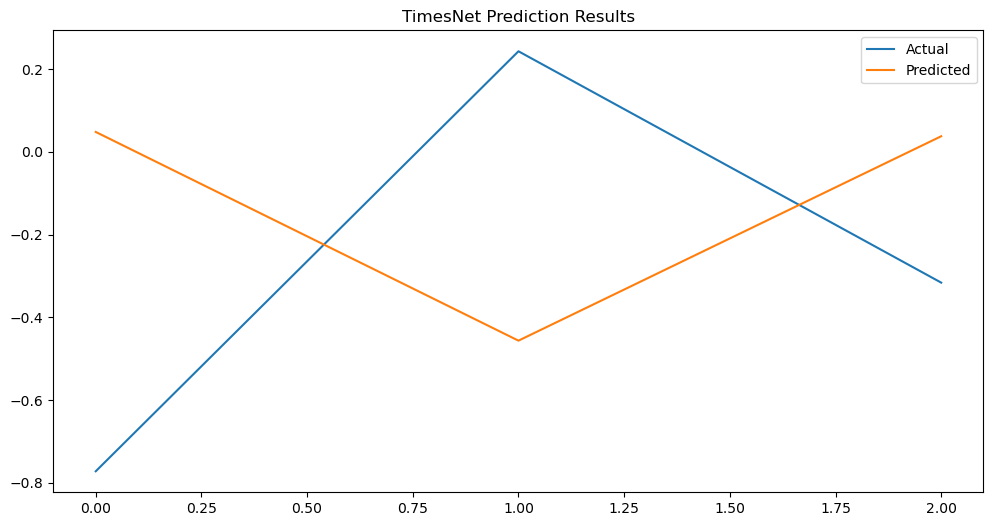

In [15]:
# 主函数  
def main():  
    # 设置设备  
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  
    
    # 加载数据 (示例使用随机数据)  
    # 实际使用时替换为您的数据加载逻辑  
    data = np.random.randn(1000, 1)  # 示例数据  
    
    # 数据标准化  
    scaler = StandardScaler()  
    data = scaler.fit_transform(data)  
    
    # 划分训练集和测试集  
    train_size = int(len(data) * 0.8)  
    train_data = data[:train_size]  
    test_data = data[train_size:]  
    
    # 创建配置  
    configs = Config()  
    
    # 创建数据集和数据加载器  
    train_dataset = TimeSeriesDataset(train_data, configs.seq_len, configs.pred_len)  
    test_dataset = TimeSeriesDataset(test_data, configs.seq_len, configs.pred_len)  
    
    train_loader = DataLoader(train_dataset, batch_size=configs.batch_size, shuffle=True)  
    test_loader = DataLoader(test_dataset, batch_size=configs.batch_size, shuffle=False)  
    
    # 初始化模型  
    model = Model(configs).to(device)  
    
    # 定义优化器和损失函数  
    optimizer = optim.Adam(model.parameters(), lr=configs.learning_rate)  
    criterion = nn.MSELoss()  
    
    # 训练循环  
    for epoch in range(configs.epochs):  
        train_loss = train_model(model, train_loader, optimizer, criterion, device)  
        test_loss, predictions, actuals = evaluate_model(model, test_loader, criterion, device)  
        
        print(f'Epoch {epoch+1}/{configs.epochs}')  
        print(f'Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')  
    
    # 保存模型  
    torch.save(model.state_dict(), 'timesnet_model.pth')  
    
    # 绘制预测结果  
    plt.figure(figsize=(12, 6))  
    plt.plot(actuals[0], label='Actual')  
    plt.plot(predictions[0], label='Predicted')  
    plt.legend()  
    plt.title('TimesNet Prediction Results')  
    plt.show()  

if __name__ == '__main__':  
    main()

预测

In [16]:
def predict(model, data):  
    model.eval()  
    with torch.no_grad():  
        output = model(  
            x_enc=data['x'],  
            x_mark_enc=None,  
        )  
    return output